In [ ]:
#importing libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# setting the device (CPU/GPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device: ", device)

#transforming data to tensors
transform = transforms.ToTensor()

# training data
train_data = MNIST(
    root = "data",
    train = True,
    download = True,
    transform=transform
)

#testing data
test_data = MNIST(
    root = "data",
    train = False,
    download = True,
    transform=transform
)

# setting dataloader for batches

train_loader = DataLoader(
    train_data,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_data,
    batch_size=64,
    shuffle=False
)

# creating the model
class DigitModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.net(x)
        
model = DigitModel().to(device)

loss_fn = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5

#training the model
for epoch in range(epochs):

    model.train()

    total_loss = 0

    for images, labels in train_loader:
        images = images.view(images.size(0), -1).to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        output = model(images)
        loss = loss_fn(output, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch: {epoch+1}/{epochs}  Loss: {total_loss:.4f}")


model.eval()
correct = 0
total = 0

#testing the model

with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(images.size(0), -1).to(device)
        labels = labels.to(device)

        output = model(images)
        predictions = output.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

# evaluating
accuracy = (correct/total)*100
print(f"Total Accuracy: {accuracy:.4f}%")


Using device:  cpu


100.0%
100.0%
100.0%
100.0%


Epoch: 1/5  Loss: 325.8495
Epoch: 2/5  Loss: 131.1485
Epoch: 3/5  Loss: 90.2055
Epoch: 4/5  Loss: 68.5273
Epoch: 5/5  Loss: 53.7152
Total Accuracy: 97.3000%


### Making a Predictive System

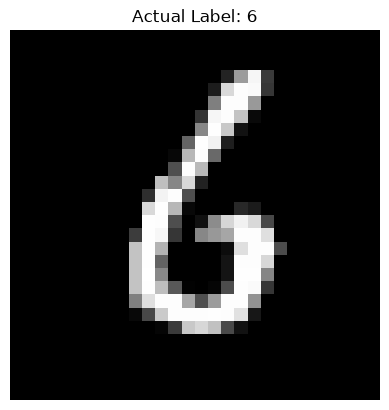

Actual Label: 6
Predicted Label: 6


In [14]:
index = 50
image, true_label = test_data[index]

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Actual Label: {true_label}")
plt.axis("off")
plt.show()

image_flat = image.view(image.size(0), -1)

with torch.no_grad():
    output = model(image_flat)
    prediction = output.argmax(dim=1)

print(f"Actual Label: {true_label}")
print(f"Predicted Label: {prediction.item()}")
    

In [ ]:
#saving the model
torch.save(model.state_dict(), "mnist_model.pth")
print("Model saved!")

Model saved!
